In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
# from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [ ]:

from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
from compressibleSPH.schemeBuilder import buildScheme
from compressibleSPH.caseUtils.sedov.initial import buildSedov
goalRadius = 0.8

gamma = 5/3
rho0 = 1
E0 = 1

nx = 200
# gamma = 5/3
# leftState = sodInitialState(1, 1, 0)
# rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

L = 2
dim = 1
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

config, integrator = buildConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = True,
    cflFactor=0.3,
)


SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('crkSPH')

compressibleSPHConfig = SimulationConfig(
    gamma = gamma,
    rho0 = rho0,
    # diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)

from compressibleSPH.enumTypes import ViscositySwitch
compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch

In [26]:
display(compressibleSPHConfig)

CompSPHConfig(gamma=1.6666666666666667, backgroundPressure=0.0, rho0=1, adaptiveSupportScheme=<AdaptiveSupportScheme.Monaghan: 1>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=True, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=2,
	Cu_l=1,
	Cu_q=2,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.CullenDehnen2010: 2>, limitXi=True, correctVelocityGradient=False, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CompSPH', energyScheme=<EnergyScheme.CRK: 5>)

In [27]:
from compressibleSPH.modules import *
from compressibleSPH.modules.timestep.compressible import computeTimestep

r_inner = 0.9
r_outer = 1.0
dx = (r_outer - r_inner) / (nx - 1)
particles_l = sampleRegularParticles(nx, config.domain, config.targetNeighbors, jitter = 0.0)


Pinitial = torch.zeros_like(particles_l.densities)
r = torch.linalg.norm(particles_l.positions, dim = -1)
rhoInitial = torch.ones_like(particles_l.densities)
v_initial = - torch.nn.functional.normalize(particles_l.positions, dim = -1)
# particles_l = particles_l._replace(masses = particles_l.masses * rhoInitial, densities = rhoInitial)

A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = particles_l.densities, gamma = gamma)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(v_initial, dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles_l.masses


simulationState = SimulationState(
    positions = particles_l.positions,
    supports = particles_l.supports,
    masses = particles_l.masses,
    densities = particles_l.densities,        
    velocities = v_initial,

    kinds = torch.zeros_like(particles_l.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_l.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_l.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter= particles_l.positions.shape[0],
    
    internalEnergies = u_,
    totalEnergies = totalEnergy,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(particles_l.densities),
    alpha0s = torch.ones_like(particles_l.densities),
    divergence = torch.zeros_like(particles_l.densities)
)
compressibleSystem = SimulationSystem(
    state=simulationState, 
    adjacency = None, 
    domain = config.domain)

dx = simulationState.masses.min()
config.dx = dx
config.dt = computeTimestep(compressibleSystem, config, compressibleSPHConfig, dt = config.dt)
config.dt = 1e-4
print(f"Initial timestep: {config.dt}")

timeLimit = 1.0
timesteps = int(timeLimit / config.dt)

print(timesteps, config.dt)

Initial timestep: 0.0001
10000 0.0001


In [28]:
rho_0 = 1
v_s = 1/3
rho_s = rho_0 * ((gamma+1) / (gamma-1))**dim
P_s = v_s * rho_s

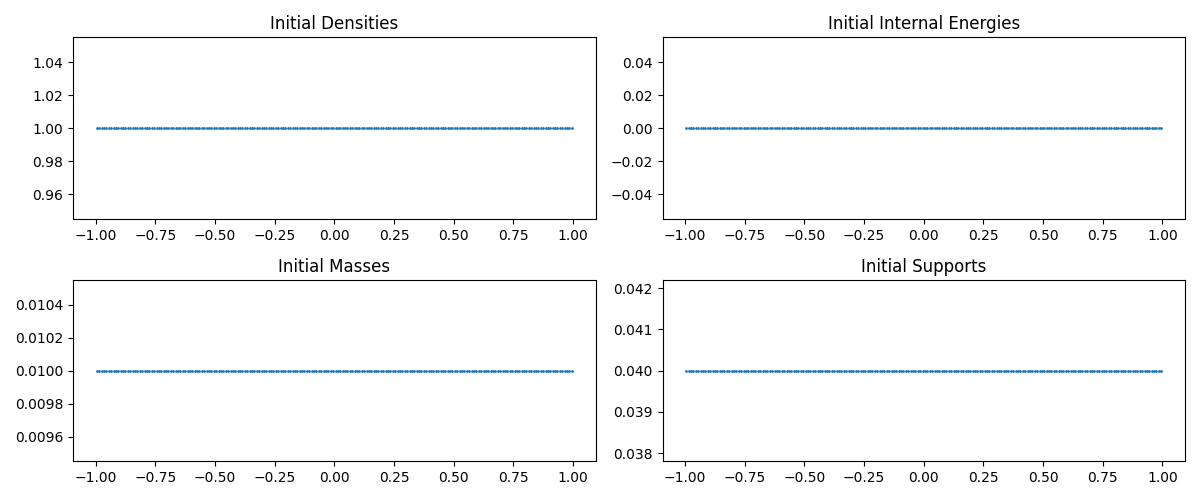

In [29]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], compressibleSystem.state.positions, compressibleSystem.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], compressibleSystem.state.positions, compressibleSystem.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], compressibleSystem.state.positions, compressibleSystem.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], compressibleSystem.state.positions, compressibleSystem.state.supports, title = 'Initial Supports')
fig.tight_layout()

In [30]:
from compressibleSPH.schemes.compSPH import compSPH_step

In [31]:
# runningState = compSystem.initializeNewState()

# result = integrator.function(
#     state = runningState,
#     f = fn,
#     dt = config.dt,  
#     config = config,
#     compParams = compressibleSPHConfig,
#     verbose = False,
# )
runningState = compressibleSystem.initializeNewState()

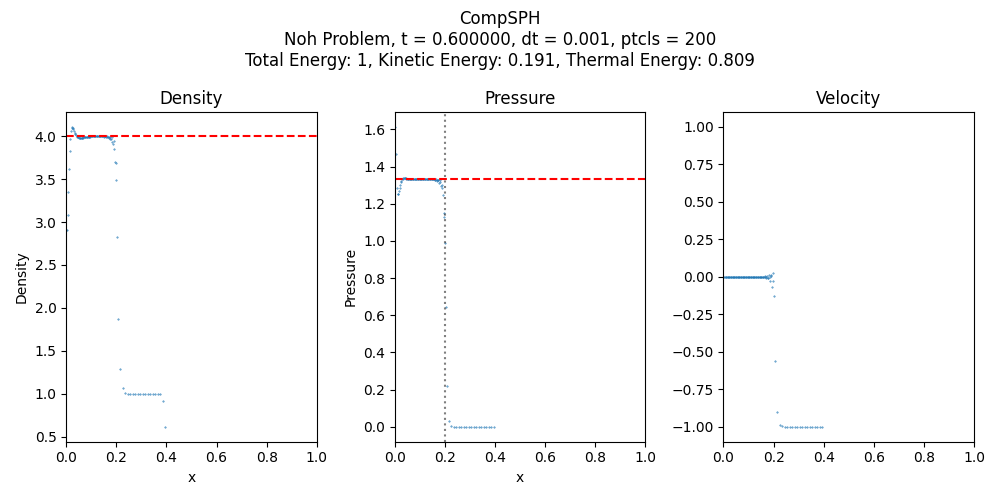

In [34]:
fig, axis = plt.subplots(1, 3, figsize = (10, 5), squeeze=False)

def plotState(fig, axis, compressibleSystem):
    for ax in axis.flatten():
        ax.cla()
    axis[0,0].scatter(compressibleSystem.state.positions.cpu(), compressibleSystem.state.densities.cpu(), s = 32/nx)
    axis[0,0].set_title('Density')
    axis[0,0].set_xlabel('x')
    axis[0,0].set_ylabel('Density')
    axis[0,0].axhline(rho_s, color = 'r', linestyle = '--')

    axis[0,1].scatter(compressibleSystem.state.positions.cpu(), compressibleSystem.state.pressures.cpu(), s = 32/nx)
    axis[0,1].set_title('Pressure')
    axis[0,1].set_xlabel('x')
    axis[0,1].set_ylabel('Pressure')
    axis[0,1].axhline(P_s, color = 'r', linestyle = '--')
    axis[0,1].axvline(v_s * compressibleSystem.t, color = 'black', linestyle = ':', alpha = 0.5)
    axis[0,1].axvline(-v_s * compressibleSystem.t, color = 'black', linestyle = ':', alpha = 0.5)

    axis[0,2].scatter(compressibleSystem.state.positions.cpu(), compressibleSystem.state.velocities.cpu()[:,0], s = 32/nx)
    axis[0,2].set_title('Velocity')


    kineticEnergy = 0.5 * (torch.linalg.norm(compressibleSystem.state.velocities, dim = -1) **2 * compressibleSystem.state.masses).sum()
    thermalEnergy = (compressibleSystem.state.internalEnergies * compressibleSystem.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy
    fig.suptitle(f'{compressibleSPHConfig.schemeName}\nNoh Problem, t = {compressibleSystem.t:2f}, dt = {config.dt:.3g}, ptcls = {len(compressibleSystem.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
    # fig.canvas.draw()
    for ax in axis.flatten():
        ax.set_xlim(0, 1)
    fig.canvas.draw()
    fig.canvas.flush_events()

plotState(fig, axis, runningState)
fig.tight_layout()


In [33]:
# config.dt = 1e-4
timeLimit = 0.6
t_limit = timeLimit
config.dt = 1e-3
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 20

runningState = compressibleSystem.initializeNewState()

trajectory = []

priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
        priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )

    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g}")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if i % 50 == 0 or i == nSteps - 1:
        plotState(fig, axis, runningState)
        # fig.tight_layout()
        fig.canvas.draw()
        fig.canvas.flush_events()

Running with dt: 0.001, which gives nSteps: 600


  0%|          | 0/600 [00:00<?, ?it/s]

In [11]:
times = [x[1] for x in trajectory]

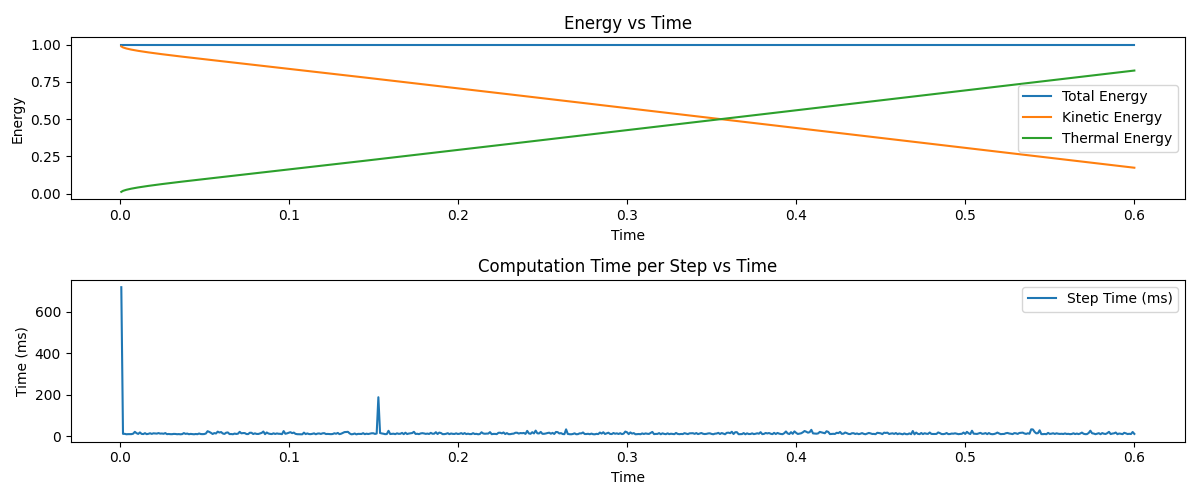

In [12]:
fig, axis = plt.subplots(2,1, figsize = (12, 5), squeeze = False)

axis[0,0].plot(times, [x[2] for x in trajectory], label = 'Total Energy')
axis[0,0].plot(times, [x[3] for x in trajectory], label = 'Kinetic Energy')
axis[0,0].plot(times, [x[4] for x in trajectory], label = 'Thermal Energy')
axis[0,0].legend()
axis[0,0].set_xlabel('Time')
axis[0,0].set_ylabel('Energy')
axis[0,0].set_title('Energy vs Time')

axis[1,0].plot(times, [x[5] for x in trajectory], label = 'Step Time (ms)')
axis[1,0].legend()
axis[1,0].set_xlabel('Time')
axis[1,0].set_ylabel('Time (ms)')
axis[1,0].set_title('Computation Time per Step vs Time')

fig.tight_layout()

In [13]:
print(f'Mean computation time per step: {sum(x[5] for x in trajectory)/len(trajectory):.3f} ms')
print(f'Max computation time for a step: {max(x[5] for x in trajectory):.3f} ms')
print(f'Stddev of computation time for steps: {torch.tensor([x[5] for x in trajectory]).std():.3f} ms')

Mean computation time per step: 14.609 ms
Max computation time for a step: 717.129 ms
Stddev of computation time for steps: 29.836 ms
